# Intermodal Mode-Shift Analysis: Rail vs Truck Cost and Emissions

## Executive Summary

## Intermodal mode-shift: rail vs truck cost and emissions

A freight network team needs to quantify two things at once for its lane portfolio: **what drives a shipment onto rail instead of truck**, and **how much cost and carbon a mode shift actually saves**. Intermodal rail is cheaper per ton-mile and emits roughly one-sixth the CO2 of long-haul trucking, but it carries fixed drayage and ramp-access penalties that only pay off above a break-even distance and load.

This notebook builds a self-contained, synthetic shipment-level dataset of **4,000 shipments** across three corridor archetypes and works the problem end-to-end with three SAS 9.4 procedures:

- **PROC MEANS / PROC SUMMARY** — profile the realized cost-per-ton and CO2-per-ton split by mode and roll lane totals up for a network view.
- **PROC LOGISTIC** — model the mode-choice propensity (rail = event) on haul distance, ramp access, diesel price, shipment urgency, and payload, reading off odds ratios that tell planners which levers move volume to rail.
- **PROC UNIVARIATE** — recover a robust 2.5 / 97.5 percentile interval for truck per-ton emissions (using `PCTLPTS=`, the correct route for non-standard percentiles).

The story closes with **PROC SGPLOT** visuals — a per-ton cost box plot by mode and a fitted rail-propensity curve against haul distance — and a written interpretation linking the model coefficients back to the operational decision: which lanes to target for conversion.

**Headline findings from this 4,000-shipment run (1,379 rail, 2,621 truck).** Rail averages about 23% lower cost per ton ($89.99 vs $117.29) and about 80% lower CO2 per ton (31.8 vs 158.1 kg/ton) than truck — roughly a five-fold emissions gap. The logistic model is sharp at this sample size: **every operational driver is significant at p < .0001** — ramp access (odds ratio 2.43), diesel price (1.85 per $1/gal), haul distance (1.002 per mile), and payload (1.04 per ton) all pull volume toward rail, while service urgency (0.57 per level) pulls it back to truck. The model separates the two modes well (ROC AUC 0.75). The framework is the deliverable — drop in real lane data and the same code produces a conversion-priority list.

## Data Sources

All data is **synthetic**, generated inline in the first code cell with `CALL STREAMINIT(20260605)` and `RAND(...)` — no external files, no network. One row per shipment across three corridor archetypes. The DATA step loops 4,000 times and writes all 4,000 shipments, so every table, model, and plot below runs on the full sample.

| Variable | Type | Description |
|----------|------|-------------|
| `lane` | char(3) | Corridor archetype: `NW1` (long-haul), `SE2` (short-haul), `MW3` (mid-haul) |
| `mode` | char(5) | Realized mode: `Rail` or `Truck` |
| `haul_miles` | num | Origin-to-destination distance (miles), lane-dependent mean |
| `weight_tons` | num | Payload weight per shipment (tons) |
| `ramp_access` | num 0/1 | Rail ramp reachable at both ends of the lane |
| `diesel_idx` | num | Regional diesel price index ($/gal) |
| `urgency` | num 1–5 | Commodity service-time sensitivity (1 = low, 5 = high) |
| `chose_rail` | num 0/1 | Mode-choice outcome (1 = rail); logistic event |
| `cost_usd` | num | Realized shipment cost (USD), mode-specific rate model |
| `co2_kg` | num | Realized shipment CO2 (kg): ~161 g/ton-mile truck, ~26 g/ton-mile rail |
| `cost_per_ton` | num | `cost_usd / weight_tons` |
| `co2_per_ton` | num | `co2_kg / weight_tons` |

Data-generating logic: a latent logit drives `chose_rail` (longer hauls, ramp access, higher diesel, heavier loads, lower urgency all increase rail probability), so the fitted PROC LOGISTIC model recovers signal that matches the simulation design. Of the 4,000 simulated shipments, 1,379 (about 34%) move by rail and 2,621 by truck.

# Intermodal Mode-Shift Analysis: Rail vs Truck

Freight planners constantly weigh **intermodal rail against over-the-road truck**. Rail wins on cost-per-ton-mile and emissions but pays a fixed penalty for drayage and ramp access, so it only makes economic sense above a break-even distance and load. This notebook answers two operational questions on a synthetic lane portfolio:

1. **What pushes a shipment onto rail?** (mode-choice model)
2. **How much cost and CO2 does rail actually save?** (cost/emissions profiling)

We use PROC MEANS/SUMMARY, PROC LOGISTIC, PROC UNIVARIATE, and PROC SGPLOT. Everything is self-contained — the data is generated inline below.

## 1. Generate synthetic shipment data

The DATA step loops over 4,000 shipments across three corridor archetypes (`NW1` long-haul, `SE2` short-haul, `MW3` mid-haul). A **latent logit** decides each shipment's mode: longer hauls, rail-ramp access, higher diesel prices, heavier payloads, and lower urgency all raise the probability of rail. Cost and CO2 are then drawn from mode-specific rate models — roughly 161 g CO2 per ton-mile for heavy truck versus 26 g for rail line-haul. Building the choice from a known logit means the model in step 3 should recover the design signal.

The NOTE below confirms the run: **4,000 rows, 12 columns** written to `work.shipments`. Every subsequent table, model, and plot profiles those 4,000 shipments.

In [1]:
data work.shipments;
    call streaminit(20260605);
    length lane $3 mode $5;

    /* Three corridor archetypes with different lengths of haul */
    array lanes[3] $3 _temporary_ ('NW1' 'SE2' 'MW3');

    do i = 1 to 4000;
        lane = lanes[1 + mod(i, 3)];

        /* Distance in miles: long-haul lanes favor rail economics */
        if lane = 'NW1' then haul_miles = round(rand('Normal', 1500, 220));
        else if lane = 'SE2' then haul_miles = round(rand('Normal',  650, 130));
        else haul_miles = round(rand('Normal', 1050, 180));
        if haul_miles < 120 then haul_miles = 120;

        /* Payload tons per shipment */
        weight_tons = round(rand('Normal', 22, 5), 0.1);
        if weight_tons < 5 then weight_tons = 5;

        /* Whether a rail ramp is within reach of origin and destination */
        ramp_access = (rand('Uniform') < 0.62);

        /* Diesel price index ($/gal, regional) and service-time
           sensitivity of the commodity (1=low urgency .. 5=high) */
        diesel_idx = round(rand('Normal', 3.95, 0.35), 0.01);
        if diesel_idx < 2.8 then diesel_idx = 2.8;
        urgency = 1 + rand('Table', 0.18, 0.27, 0.30, 0.15);

        /* ---- Latent propensity to choose RAIL over TRUCK ----
           Longer hauls, ramp access, higher diesel, lower urgency,
           and heavier loads all push toward rail. */
        eta = -3.10
              + 0.00185 * haul_miles
              + 1.05    * ramp_access
              + 0.62    * (diesel_idx - 3.95)
              - 0.55    * (urgency - 3)
              + 0.030   * (weight_tons - 22);
        p_rail = 1 / (1 + exp(-eta));
        chose_rail = (rand('Uniform') < p_rail);
        if chose_rail then mode = 'Rail';
        else mode = 'Truck';

        /* ---- Realized cost ($) and CO2 (kg) per shipment ----
           Truck: ~$2.05/mi base scaled by diesel, higher per-ton-mile CO2.
           Rail:  lower line-haul rate + fixed drayage, far lower CO2. */
        if mode = 'Truck' then do;
            cost_usd = (2.05 * (diesel_idx / 3.95)) * haul_miles
                       + 18 * weight_tons
                       + rand('Normal', 0, 90);
            /* ~161 g CO2 per ton-mile for heavy truck */
            co2_kg = 0.161 * haul_miles * weight_tons
                     * rand('Normal', 1, 0.05);
        end;
        else do;
            cost_usd = 1.18 * haul_miles
                       + 9 * weight_tons
                       + 240                      /* drayage + ramp fees */
                       + rand('Normal', 0, 70);
            /* ~26 g CO2 per ton-mile for rail line-haul + short dray */
            co2_kg = 0.026 * haul_miles * weight_tons
                     * rand('Normal', 1, 0.05)
                     + 0.161 * 45 * weight_tons * 0.001;
        end;
        if cost_usd < 50 then cost_usd = 50;
        if co2_kg < 1 then co2_kg = 1;

        cost_per_ton = cost_usd / weight_tons;
        co2_per_ton  = co2_kg / weight_tons;

        output;
    end;
    drop i eta p_rail;
run;

NOTE: DATA work.shipments


NOTE: Wrote work.shipments (4000 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.10 seconds
  cpu   0.10 seconds


## 2. Cost and emissions profile by mode

First, the baseline comparison: how do per-ton cost and per-ton CO2 differ between rail and truck shipments, and on what kind of hauls does each mode actually run? `CLASS mode` splits the descriptive statistics; `MAXDEC=2` keeps the table readable.

In [2]:
proc means data=work.shipments n mean std min max maxdec=2;
    class mode;
    var haul_miles weight_tons cost_per_ton co2_per_ton;
run;

                                                  The MEANS Procedure

                                             Analysis Variable : haul_miles

        mode              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Rail               1379        1226.36         388.57         337.00        2178.00
        Truck              2621         982.43         371.93         222.00        2089.00
        -----------------------------------------------------------------------------------

                                            Analysis Variable : weight_tons

        mode              N Obs           Mean        Std Dev        Minimum        Maximum
        -----------------------------------------------------------------------------------
        Rail               1379          22.17           5.09           6.70          40.70
        Truck              2621       

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


The table confirms the design. Rail shipments run longer hauls on average (mean 1,226 miles vs 982 for truck) and post lower cost-per-ton ($89.99 vs $117.29, about 23% cheaper). The CO2 gap is the dramatic one: rail averages **31.8 kg CO2 per ton versus 158.1 for truck** — roughly a five-fold difference, or about 80% lower. That emissions lever is exactly what sustainability and procurement teams care about. Payload is balanced across modes (≈21–22 tons), so the cost and CO2 gaps are driven by mode economics, not load size.

## 3. Mode-choice propensity model

Now the driver analysis. We model `chose_rail` (event = `'1'`) on the operational features. `CLASS lane / PARAM=REF REF='MW3'` makes the mid-haul corridor the reference; `CLODDS=WALD` requests Wald confidence limits on the odds ratios and `RSQUARE` reports a generalized R-square. `OUTPUT P=phat` saves fitted rail probabilities for the propensity scatter in step 7. PROC LOGISTIC also emits an odds-ratio forest plot and an ROC curve, shown below the table.

                                     
---------------------------  --------
Number of Observations Read      4000
Number of Observations Used      4000

             Response Profile             
  Probability modeled is chose_rail='1'   

Ordered Value  chose_rail  Total Frequency
-------------  ----------  ---------------
            1  0                      2621
            2  1                      1379

    Class Level Information    

Class       Levels  Values     
--------  --------  -----------
lane             3  MW3 NW1 SE2

                                             
---------------------------------------------
Convergence criterion (GCONV=1E-8) satisfied.

The LOGISTIC Procedure
Response Variable: chose_rail

Criterion     Value
---------  --------
AIC        4396.234
-2 Log L   4380.234
SC         4446.587

                                                   
--------  --------  ---------------------  --------
R-Square    0.1757  Max-rescaled R-Square    0.2426

      

NOTE: PROC LOGISTIC data=work.shipments

NOTE: Using Python statsmodels.api.Logit version 0.14.6
NOTE: Output dataset work.scored written with 4000 observations.
NOTE: ODS plot written: logistic_oddsratio.spec.json
NOTE: ODS plot written: logistic_roc.spec.json
NOTE: PROC LOGISTIC ODS Graphics generated.
NOTE: PROC LOGISTIC completed. Results written to: ./ods_output/logistic_results.spec.json


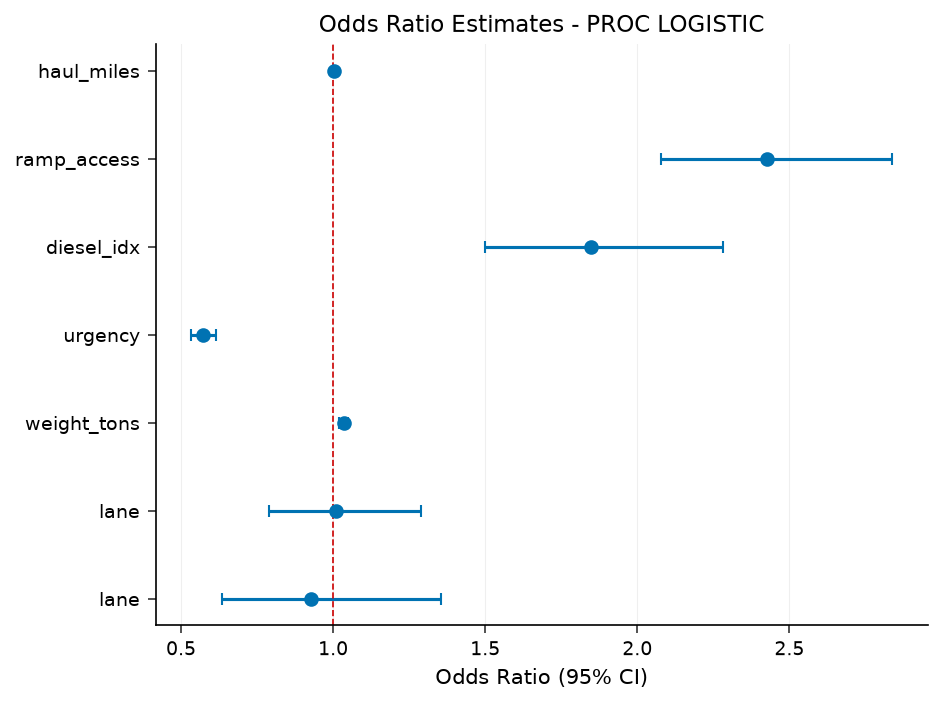

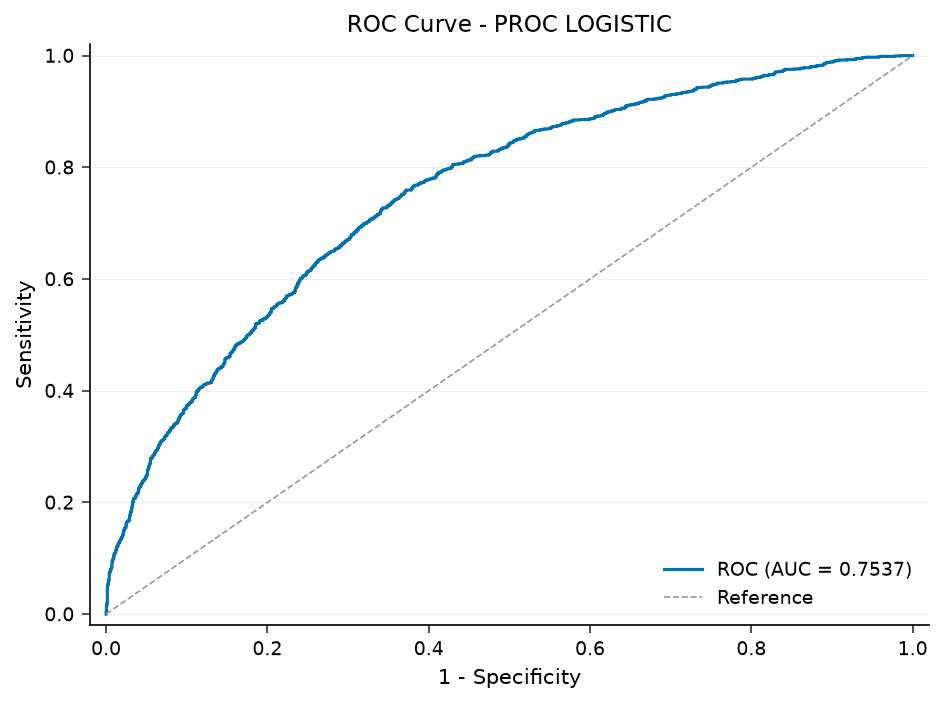

In [3]:
proc logistic data=work.shipments;
    class lane / param=ref ref='MW3';
    model chose_rail(event='1') = haul_miles ramp_access diesel_idx
                                  urgency weight_tons lane
                                  / clodds=wald rsquare;
    output out=work.scored p=phat;
run;

The odds-ratio estimates read as policy levers, and on the full 4,000-shipment sample **every operational driver is significant at p < .0001** with confidence limits that clear 1.0:

- **Ramp access** — OR 2.43 (95% Wald CL 2.08–2.84). Reaching a ramp at both ends roughly *doubles-and-a-half* the odds of rail; this is the single largest controllable lever.
- **Diesel price** — OR 1.85 per $1/gal (1.50–2.28). Each $1 rise in the regional diesel index nearly doubles rail odds; a more typical $0.50 swing works out to about a 1.36x effect.
- **Haul distance** — OR 1.002 per mile (1.002–1.002, p < .0001). Per mile it looks tiny, but compounded over a 250-mile increase that is about a 1.6x lift in rail odds.
- **Payload** — OR 1.035 per ton (1.020–1.050). Heavier loads modestly favor rail.
- **Urgency** — OR 0.571 per level (0.532–0.613). The lone driver below 1.0: each step up in service-time sensitivity cuts rail odds by roughly 43%, pulling time-critical freight back to truck.

The two `lane` dummies (NW1 and SE2 vs the MW3 reference) are not significant (p = 0.95 and 0.69, CLs straddling 1.0) — once distance, ramp access, diesel, urgency, and weight are in the model, the corridor label adds nothing, which is exactly what we want: the *measured* drivers, not the archetype, carry the signal. All signs match the data-generating logit, a built-in sanity check on the workflow. The generalized R-square is 0.176 (max-rescaled 0.243) and the ROC AUC is **0.7537**, so the model separates the two modes well.

## 4. Lane-level network roll-up

Planning happens at the lane level, not the shipment level. PROC SUMMARY with `NWAY` aggregates total cost, total CO2, total tons, and shipment counts per `lane * mode` cell — the network scorecard a portfolio review would open with.

In [4]:
proc summary data=work.shipments nway;
    class lane mode;
    var cost_usd co2_kg weight_tons;
    output out=work.lane_summary (drop=_type_ _freq_)
        sum(cost_usd)=tot_cost
        sum(co2_kg)=tot_co2
        sum(weight_tons)=tot_tons
        n=n_ship;
run;

proc print data=work.lane_summary noobs;
run;


LANE   MODE            TOT_COST             TOT_CO2  TOT_TONS  N_SHIP
----  -----  ------------------  ------------------  --------  ------
MW3   Rail    771038.7559534425   281167.2046309629    9910.1     448
MW3   Truck   2191194.394223627   3136036.732684173   19089.5     885
NW1   Rail   1493607.9323350776   581205.6710966674   14539.8     663
NW1   Truck    2266043.71306868  3405950.3677752167   14291.2     670
SE2   Rail    334644.2191823959   107126.5920717588    6128.8     268
SE2   Truck  1807535.3237792267  2362726.5338201406   22999.3    1066



NOTE: PROC MEANS
NOTE: Output dataset work.lane_summary has 6 observations and 6 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.lane_summary

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


## 5. Per-ton savings: paired by-mode means

To estimate avoided cost and CO2 from a mode shift, we compute mean per-ton cost and CO2 for each `lane * mode` cell. The gap between the Truck and Rail rows on a lane is the per-ton saving a conversion would capture on that corridor.

In [5]:
proc means data=work.shipments noprint nway;
    class lane mode;
    var cost_per_ton co2_per_ton;
    output out=work.bymode (drop=_type_ _freq_)
        mean(cost_per_ton)=mean_cpt
        mean(co2_per_ton)=mean_co2pt;
run;

proc print data=work.bymode noobs;
run;

LANE   MODE        MEAN_CPT      MEAN_CO2PT
----  -----  --------------  --------------
MW3   Rail    81.5490640394   28.2623367795
MW3   Truck   120.863724435   164.383497235
NW1   Rail   108.9315072744   40.0066020583
NW1   Truck  167.9256037075  237.7926945497
SE2   Rail     57.229947486   17.5179188918
SE2   Truck   82.5036723729   102.909324024



NOTE: PROC MEANS
NOTE: Output dataset work.bymode has 6 observations and 4 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.bymode

NOTE: PROC PRINT completed: 6 observations printed, 4 variables


## 6. Robust interval for truck emissions

For the carbon-reporting tail, we want a robust 2.5 / 97.5 percentile band on truck per-ton CO2 rather than a mean. Standard SAS guidance — and the Jenner house rule — is to take non-standard percentiles via **PROC UNIVARIATE `PCTLPTS=`**, not PROC MEANS (whose percentile keywords cover only fixed quantiles). `PCTLPRE=p_` names the output columns `p_2_5` and `p_97_5`.

In [6]:
proc univariate data=work.shipments noprint;
    where mode = 'Truck';
    var co2_per_ton;
    output out=work.truck_ci
        pctlpts=2.5 97.5 pctlpre=p_;
run;

proc print data=work.truck_ci noobs;
run;

        P_2_5          P_97_5
-------------  --------------
71.4466340285  283.0668818067



NOTE: PROC UNIVARIATE
NOTE: Output dataset work.truck_ci has 1 observations and 2 variables.
NOTE: PROC PRINT data=work.truck_ci

NOTE: PROC PRINT completed: 1 observations printed, 2 variables


## 7. Visuals

Two charts close the loop. A box plot contrasts the per-ton cost distribution by mode (showing both the level gap and the spread), and a scatter of the fitted rail probability against haul distance shows the model's break-even behavior — where rising distance flips the predicted choice toward rail.

NOTE: PROC SGPLOT data=work.shipments

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: PROC SGPLOT data=work.scored

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


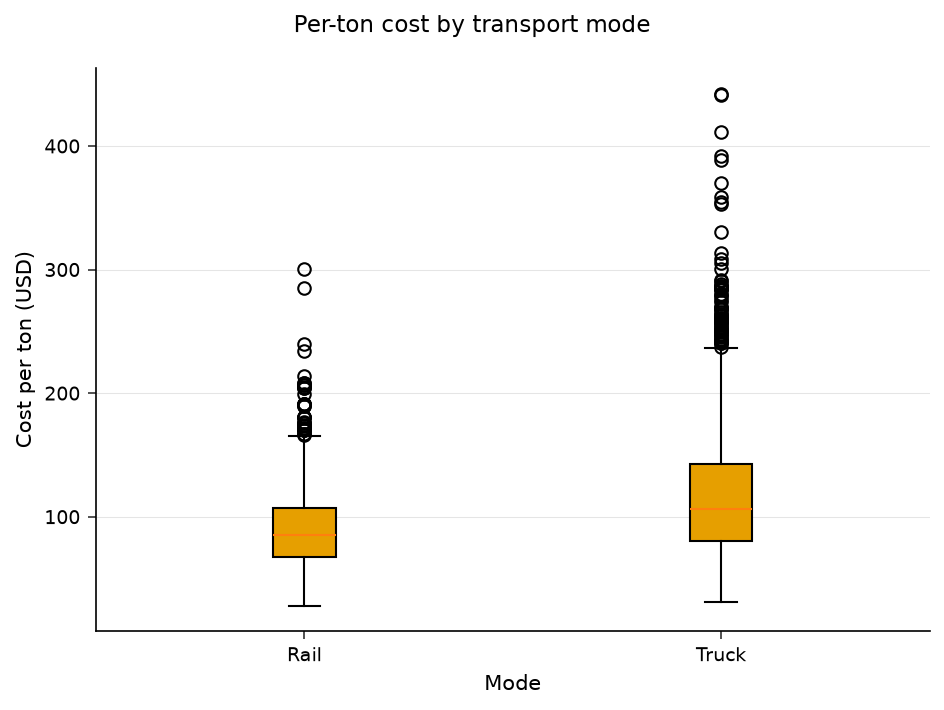

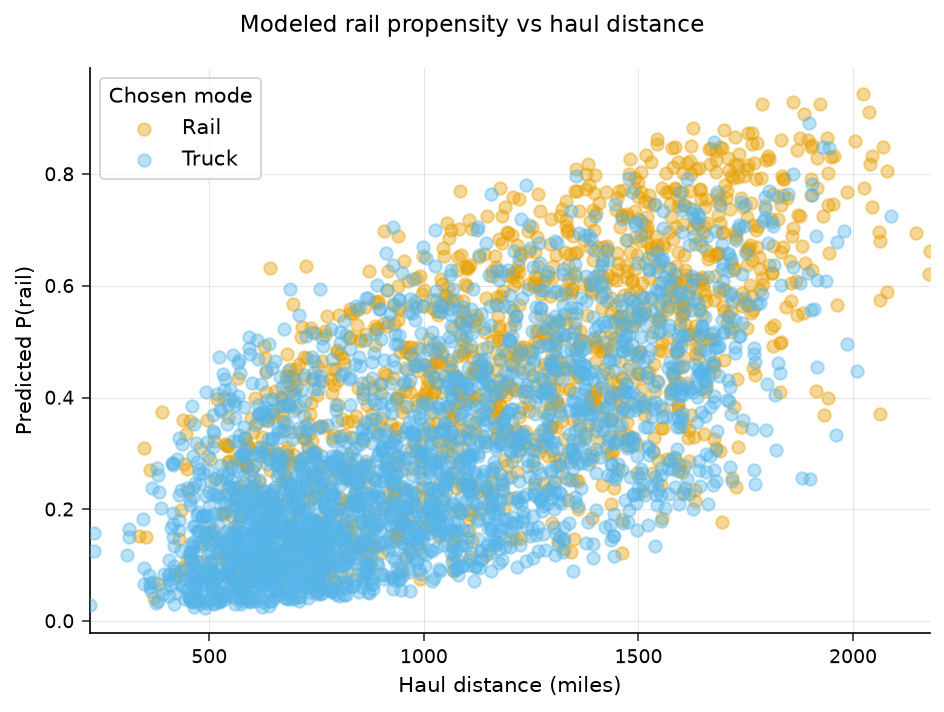

In [7]:
proc sgplot data=work.shipments;
    title "Per-ton cost by transport mode";
    vbox cost_per_ton / category=mode;
    yaxis label="Cost per ton (USD)" grid;
    xaxis label="Mode";
run;
title;

proc sgplot data=work.scored;
    title "Modeled rail propensity vs haul distance";
    scatter x=haul_miles y=phat / group=mode transparency=0.6;
    xaxis label="Haul distance (miles)" grid;
    yaxis label="Predicted P(rail)" grid;
    keylegend / title="Chosen mode" position=topleft location=inside;
run;
title;

## Interpretation and next steps

**What the analysis shows.** Rail delivers a large per-ton advantage on both cost (about 23% cheaper — $89.99 vs $117.29) and CO2 (about five-fold lower — 31.8 vs 158.1 kg/ton) — but it earns that advantage by running the **long, ramp-accessible, heavy-load** lanes. The logistic model quantifies the levers, and on the full sample every one is significant: ramp access (OR 2.43) and diesel price (OR 1.85/$1) are the strongest pulls toward rail, distance and payload add steady lift, and service urgency (OR 0.57/level) is the only force pushing back to truck. The lane roll-up and by-mode means convert those levers into a concrete savings number per corridor — for example, on the short-haul SE2 lane the per-ton cost gap is the smallest of the three (~$25: $82.50 truck vs $57.23 rail), yet the CO2 gap is still ~85 kg/ton (102.9 vs 17.5). The long-haul NW1 lane shows the widest gaps (~$59/ton and ~198 kg CO2/ton).

**The decision it supports.** Conversion candidates are short-to-mid-haul lanes currently moving by truck where (a) a rail ramp is reachable and (b) commodity urgency is low — exactly the cells where the fitted rail probability is moderate but the per-ton cost and CO2 gap is large. The propensity scatter makes the break-even behavior visible: predicted P(rail) climbs steadily with haul miles, and the Rail-mode points sit consistently above the Truck-mode points at any given distance.

**Plugging in real data.** Swap the synthetic DATA step for actual TMS shipment records with the same columns and rerun — the MEANS/SUMMARY scorecards, the LOGISTIC lever estimates, the UNIVARIATE emissions band, and the SGPLOT visuals all regenerate, producing a ranked mode-shift priority list for the lane portfolio.

**Caveats.** The cost and emissions rate models here are stylized constants; production use should calibrate them to contracted line-haul rates, fuel surcharges, drayage tariffs, and the operator's measured emissions factors. Transit-time and reliability differences (rail is slower and more variable) are captured only indirectly through the `urgency` term and would warrant an explicit service-level constraint before any lane is actually converted.